**07 — SDF baseline for full-phase sparse tumor-mask interpolation**

This notebook provides a simple geometric baseline for the final MedGS experiment on patient 117, respiratory phase 0%.

The baseline receives **exactly the same observed tumor masks** as the full-phase MedGS run and reconstructs the missing masks by linear interpolation of 2D signed distance fields (SDFs).

It does not train a neural network and does not use CT intensities. Its purpose is to answer a direct question:

> How much of the sparse-slice tumor reconstruction can be obtained from simple geometric interpolation of the observed masks alone?

The final comparison therefore uses:

- the same patient and respiratory phase;
- the same observed slice indices;
- the same held-out tumor slices;
- the same 2D Dice/IoU evaluation;
- the same upstream MedGS mesh-construction script and the same 3D mesh metrics.

# 1. Data and reference MedGS experiment

The full CT phase contains slices `0..146`.

Rather than reconstructing the sparse sampling pattern independently, this notebook reads `observed_slices.csv` produced by the completed full-phase MedGS experiment. This guarantees that the SDF baseline uses exactly the same observed masks.

For this experiment the observed indices are:

`0, 2, 5, 8, 11, ..., 146`

and the tumor is present in the ground truth on slices `86..92`.

The observed tumor masks are `86`, `89`, `92`; the held-out tumor masks are `87`, `88`, `90`, `91`.

In [1]:
from pathlib import Path
from typing import Any

import json
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
from scipy.ndimage import distance_transform_edt

from medgs4d.data import (
    load_phase_volume,
    load_study_manifest,
    window_hu_to_uint8,
)
from medgs4d.mesh_transfer import evaluate_mesh_against_reference
from medgs4d.meshes import (
    TriangleMesh,
    binary_dice,
    binary_iou,
    load_mesh_npz,
    write_ply,
)
from medgs4d.rtstruct import load_geometry
from medgs4d.sparse_joint_visualization import (
    show_sparse_joint_anatomy_3d,
)

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
MEDGS_REPO = STACK_ROOT / "repo" / "MedGS"

STUDY_DIR = (
    STACK_ROOT
    / "data"
    / "tcia_4d_lung"
    / "prepared"
    / "patient117_20001024_annotated"
)

PHASE = 0.0
REPRESENTATION = "denoised"
PHASE_TAG = f"{int(PHASE):02d}"

TUMOR_START = 86
TUMOR_END = 92

MEDGS_ROOT = (
    STACK_ROOT
    / "results"
    / "canonical"
    / STUDY_DIR.name
    / "phase00_joint_full_stride3_poly7_lseg2_bginter_v13"
)

MEDGS_RUN = MEDGS_ROOT / "medgs"
MEDGS_EVAL = MEDGS_RUN / "evaluation"

SDF_RUN = MEDGS_ROOT / "sdf_baseline"
SDF_MASK_DIR = SDF_RUN / "dense_mask"
SDF_EVAL_DIR = SDF_RUN / "evaluation"

MESH_THRESHOLD = 0

# An empty binary mask has no zero level set, so its mathematical SDF is
# undefined. For this simple baseline we use a fixed value of -1 pixel.
# This is a fixed convention, not a parameter selected on held-out GT.
EMPTY_SDF_LEVEL = -1.0

PHASE_DIR = (
    STUDY_DIR
    / "rtstruct_mesh"
    / "tumor_4d"
    / f"phase_{PHASE_TAG}"
)

print("MedGS reference run:", MEDGS_RUN)
print("SDF baseline output:", SDF_RUN)

MedGS reference run: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs
SDF baseline output: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline


In [2]:
study = load_study_manifest(STUDY_DIR)

ct_hu = np.asarray(
    load_phase_volume(
        study,
        PHASE,
        representation=REPRESENTATION,
        mmap_mode="r",
    )
)

reference_mask = np.load(
    PHASE_DIR / "mask.npy",
    allow_pickle=False,
).astype(bool)

geometry = load_geometry(PHASE_DIR / "geometry.json")
reference_mesh = load_mesh_npz(PHASE_DIR / "mesh_raw.npz")

assert ct_hu.shape == reference_mask.shape == geometry.shape_zyx
assert ct_hu.shape[0] == 147

observed_manifest = pd.read_csv(
    MEDGS_ROOT / "observed_slices.csv"
)

observed_slices = (
    observed_manifest["SliceIndex"]
    .astype(int)
    .tolist()
)

evaluation_slices = list(range(ct_hu.shape[0]))
observed_set = set(observed_slices)

missing_slices = [
    i for i in evaluation_slices
    if i not in observed_set
]

tumor_slices = list(
    range(TUMOR_START, TUMOR_END + 1)
)

tumor_missing_slices = [
    i for i in tumor_slices
    if i not in observed_set
]

observed_tumor_slices = [
    i for i in observed_slices
    if reference_mask[i].any()
]

observed_empty_slices = [
    i for i in observed_slices
    if not reference_mask[i].any()
]

assert observed_slices[0] == 0
assert observed_slices[-1] == 146
assert observed_tumor_slices == [86, 89, 92]
assert tumor_missing_slices == [87, 88, 90, 91]

print("Observed slices:")
display(observed_manifest)

print("Held-out tumor slices:", tumor_missing_slices)

Observed slices:


,FrameIndex,SliceIndex,TumorMask
0,0,0,False
1,1,2,False
2,2,5,False
3,3,8,False
4,4,11,False
5,5,14,False
6,6,17,False
7,7,20,False
8,8,23,False
9,9,26,False


Held-out tumor slices: [87, 88, 90, 91]


# 2. Signed distance interpolation

For a non-empty binary mask $M$, the signed distance field is defined here as:

$$
D(M)
=
D_{\mathrm{inside}}(M)
-
D_{\mathrm{outside}}(M)
$$

so:

- values are positive inside the tumor;
- values are negative outside the tumor;
- the tumor boundary is the zero level set.

For two consecutive observed masks $A$ and $B$, a missing slice at relative position $\alpha$ is reconstructed by:

$$
D_{\alpha}
=
(1-\alpha)D(A)
+
\alpha D(B)
$$

and converted back to a binary mask using:

$$
\hat{M}_{\alpha}
=
D_{\alpha} > 0
$$

This gives a simple shape interpolation: boundaries move smoothly because distances, rather than binary pixel values, are interpolated.

### Empty masks

A completely empty mask has no boundary and therefore no ordinary signed distance field. The baseline uses a fixed constant value of `-1` pixel for an empty observed mask.

This convention has two useful properties:

- `empty -> empty` remains empty throughout the interval;
- `empty -> tumor` and `tumor -> empty` can create or remove a tumor smoothly as the interpolated signed distance crosses zero.

The value is fixed before evaluation and is not tuned on the held-out tumor masks.

### What the baseline does not use

The SDF baseline does not see:

- CT intensities;
- MedGS Gaussian geometry;
- image reconstruction loss;
- Dice loss;
- background-aware MedGS loss.

It uses only the sparse observed binary masks and their slice positions.

In [3]:
def mask_to_sdf(mask: np.ndarray) -> np.ndarray:
    """Convert one binary mask to a signed distance field in pixel units."""

    mask = np.asarray(mask, dtype=bool)

    if not mask.any():
        return np.full(
            mask.shape,
            EMPTY_SDF_LEVEL,
            dtype=np.float32,
        )

    inside = distance_transform_edt(mask)
    outside = distance_transform_edt(~mask)

    return (
        inside - outside
    ).astype(np.float32)


observed_sdfs = {
    slice_index: mask_to_sdf(
        reference_mask[slice_index]
    )
    for slice_index in observed_slices
}

print(
    "Prepared signed distance fields for",
    len(observed_sdfs),
    "observed masks.",
)

Prepared signed distance fields for 50 observed masks.


# 3. Dense SDF reconstruction

Every observed mask is copied exactly.

For each missing slice, the notebook finds the nearest observed mask on the left and right, computes its relative position $\alpha$ inside that interval, linearly interpolates the two SDFs, and thresholds the result at zero.

No model is fitted and there are no training iterations.

In [4]:
SDF_RUN.mkdir(parents=True, exist_ok=True)
SDF_EVAL_DIR.mkdir(parents=True, exist_ok=True)

shutil.rmtree(
    SDF_MASK_DIR,
    ignore_errors=True,
)
SDF_MASK_DIR.mkdir(parents=True)

predicted_sdf = np.empty(
    reference_mask.shape,
    dtype=np.float32,
)

predicted_mask = np.zeros(
    reference_mask.shape,
    dtype=bool,
)

interpolation_rows = []

observed_array = np.asarray(
    observed_slices,
    dtype=int,
)

for slice_index in evaluation_slices:
    if slice_index in observed_set:
        predicted_sdf[slice_index] = (
            observed_sdfs[slice_index]
        )
        predicted_mask[slice_index] = (
            reference_mask[slice_index]
        )

        interpolation_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": True,
                "LeftObserved": slice_index,
                "RightObserved": slice_index,
                "Alpha": 0.0,
            }
        )
        continue

    right_position = int(
        np.searchsorted(
            observed_array,
            slice_index,
        )
    )
    left_position = right_position - 1

    left_slice = int(
        observed_array[left_position]
    )
    right_slice = int(
        observed_array[right_position]
    )

    alpha = (
        (slice_index - left_slice)
        / (right_slice - left_slice)
    )

    sdf = (
        (1.0 - alpha)
        * observed_sdfs[left_slice]
        + alpha
        * observed_sdfs[right_slice]
    )

    predicted_sdf[slice_index] = sdf
    predicted_mask[slice_index] = sdf > 0.0

    interpolation_rows.append(
        {
            "SliceIndex": slice_index,
            "Observed": False,
            "LeftObserved": left_slice,
            "RightObserved": right_slice,
            "Alpha": float(alpha),
        }
    )

for slice_index in evaluation_slices:
    Image.fromarray(
        predicted_mask[slice_index].astype(
            np.uint8
        )
        * 255
    ).save(
        SDF_MASK_DIR
        / f"{slice_index:04d}.png"
    )

np.save(
    SDF_RUN / "dense_sdf.npy",
    predicted_sdf,
)

interpolation_table = pd.DataFrame(
    interpolation_rows
)
interpolation_table.to_csv(
    SDF_RUN / "interpolation_mapping.csv",
    index=False,
)

config = {
    "method": "2D signed-distance interpolation",
    "phase": PHASE,
    "observed_slices": observed_slices,
    "tumor_slices": tumor_slices,
    "empty_sdf_level": EMPTY_SDF_LEVEL,
    "sdf_threshold": 0.0,
    "mesh_threshold": MESH_THRESHOLD,
}

(
    SDF_RUN / "experiment_config.json"
).write_text(
    json.dumps(
        config,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("Dense SDF reconstruction complete.")
print("Reconstructed missing slices:", len(missing_slices))

Dense SDF reconstruction complete.
Reconstructed missing slices: 97


# 4. 2D mask evaluation

The primary result is again the `tumor_missing` split: slices `87`, `88`, `90`, `91`.

The `all` and `missing_all` averages are also reported for completeness, but they contain many empty slices. Empty ground truth and empty prediction receive Dice `1`, so those aggregate numbers are naturally high.

For this reason, the held-out tumor Dice and IoU are the most informative direct comparison with MedGS.

In [5]:
rows = []

for slice_index in evaluation_slices:
    gt_mask = reference_mask[slice_index]
    pred_mask = predicted_mask[slice_index]

    rows.append(
        {
            "SliceIndex": slice_index,
            "Observed": slice_index in observed_set,
            "TumorGT": bool(gt_mask.any()),
            "GTPixels": int(gt_mask.sum()),
            "PredictedPixels": int(pred_mask.sum()),
            "Dice": binary_dice(
                pred_mask,
                gt_mask,
            ),
            "IoU": binary_iou(
                pred_mask,
                gt_mask,
            ),
        }
    )

sdf_per_slice = pd.DataFrame(rows)

missing_frame = sdf_per_slice[
    ~sdf_per_slice["Observed"]
]

tumor_missing_frame = sdf_per_slice[
    sdf_per_slice["SliceIndex"].isin(
        tumor_missing_slices
    )
]

empty_missing_frame = missing_frame[
    ~missing_frame["TumorGT"]
]

summary_rows = []

for name, frame in [
    ("all", sdf_per_slice),
    (
        "observed",
        sdf_per_slice[
            sdf_per_slice["Observed"]
        ],
    ),
    ("missing_all", missing_frame),
    ("tumor_missing", tumor_missing_frame),
    ("empty_missing", empty_missing_frame),
]:
    summary_rows.append(
        {
            "Split": name,
            "Slices": len(frame),
            "Dice": float(
                frame["Dice"].mean()
            ),
            "IoU": float(
                frame["IoU"].mean()
            ),
        }
    )

sdf_summary = pd.DataFrame(summary_rows)

sdf_per_slice.to_csv(
    SDF_EVAL_DIR / "mask_per_slice.csv",
    index=False,
)

sdf_summary.to_csv(
    SDF_EVAL_DIR / "mask_summary.csv",
    index=False,
)

print("SDF mask reconstruction metrics:")
display(sdf_summary)

print("SDF held-out tumor slices:")
display(
    sdf_per_slice[
        sdf_per_slice["SliceIndex"].isin(
            tumor_missing_slices
        )
    ][
        [
            "SliceIndex",
            "GTPixels",
            "PredictedPixels",
            "Dice",
            "IoU",
        ]
    ]
)

SDF mask reconstruction metrics:


,Split,Slices,Dice,IoU
0,all,147,0.965006,0.960883
1,observed,50,1.000000,1.000000
2,missing_all,97,0.946968,0.940719
3,tumor_missing,4,0.713962,0.562435
4,empty_missing,93,0.956989,0.956989


SDF held-out tumor slices:


,SliceIndex,GTPixels,PredictedPixels,Dice,IoU
87,87,581,257,0.613365,0.442341
88,88,583,384,0.794209,0.658662
90,90,422,328,0.808000,0.677852
91,91,385,196,0.640275,0.470886


In [6]:
empty_indices = [
    i for i in evaluation_slices
    if i not in tumor_slices
]

observed_empty_indices = [
    i for i in observed_slices
    if i not in tumor_slices
]

extent = {
    "FalsePositivePixelsOutsideTumor": int(
        predicted_mask[empty_indices].sum()
    ),
    "PositiveSlicesOutsideTumor": int(
        predicted_mask[empty_indices]
        .reshape(len(empty_indices), -1)
        .any(axis=1)
        .sum()
    ),
    "PositiveObservedEmptySlices": int(
        predicted_mask[observed_empty_indices]
        .reshape(
            len(observed_empty_indices),
            -1,
        )
        .any(axis=1)
        .sum()
    ),
}

(
    SDF_EVAL_DIR
    / "extent_metrics.json"
).write_text(
    json.dumps(
        extent,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("SDF mask extent:")
display(pd.DataFrame([extent]))

SDF mask extent:


,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,523,4,0


# 5. Mesh reconstruction

For a fair 3D comparison, the SDF baseline does not use a separate custom meshing method.

The reconstructed binary mask stack is written as 0/255 PNG slices and passed to the same upstream MedGS `slices_to_ply.py` script used for the final MedGS reconstruction.

Mesh evaluation then uses exactly the same reference mesh and the same metrics:

- Dice;
- IoU;
- Mean Surface Distance;
- HD95;
- centroid error;
- volume error;
- surface-area error.

In [7]:
mesh_input_root = SDF_RUN / "mesh_input"
mesh_case_dir = (
    mesh_input_root
    / "case"
    / "render"
)
mesh_output_dir = SDF_RUN / "mesh"

shutil.rmtree(
    mesh_input_root,
    ignore_errors=True,
)
shutil.rmtree(
    mesh_output_dir,
    ignore_errors=True,
)

mesh_case_dir.mkdir(parents=True)
mesh_output_dir.mkdir(parents=True)

for local_index, slice_index in enumerate(
    evaluation_slices
):
    Image.fromarray(
        predicted_mask[slice_index].astype(
            np.uint8
        )
        * 255
    ).save(
        mesh_case_dir
        / f"{local_index:05d}_0.png"
    )

print("Building SDF baseline tumor mesh.")

mesh_command = [
    sys.executable,
    str(MEDGS_REPO / "slices_to_ply.py"),
    "--input", str(mesh_input_root),
    "--output", str(mesh_output_dir),
    "--thresh", str(MESH_THRESHOLD),
    "--inter", "1",
]

subprocess.run(
    mesh_command,
    cwd=MEDGS_REPO,
    check=True,
)

import open3d as o3d

mesh_path = mesh_output_dir / "case.ply"

o3d_mesh = o3d.io.read_triangle_mesh(
    str(mesh_path)
)

vertices_zyx = np.asarray(
    o3d_mesh.vertices,
    dtype=np.float64,
).copy()

faces = np.asarray(
    o3d_mesh.triangles,
    dtype=np.int64,
)

vertices_xyz = (
    geometry.index_zyx_to_patient_xyz(
        vertices_zyx
    )
)

sdf_mesh = TriangleMesh(
    vertices_zyx=vertices_zyx,
    vertices_xyz=vertices_xyz,
    faces=faces,
)

write_ply(
    mesh_output_dir
    / "case_patient_coordinates.ply",
    vertices_xyz,
    faces,
)

sdf_mesh_metrics = (
    evaluate_mesh_against_reference(
        sdf_mesh,
        reference_mesh,
        reference_mask,
        geometry,
    )
)

sdf_mesh_metrics.pop("CandidateMask")

sdf_mesh_metrics = {
    key: (
        value.item()
        if isinstance(value, np.generic)
        else value
    )
    for key, value
    in sdf_mesh_metrics.items()
}

(
    SDF_EVAL_DIR
    / "mesh_metrics.json"
).write_text(
    json.dumps(
        sdf_mesh_metrics,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("SDF mesh reconstruction metrics:")
display(
    pd.DataFrame(
        {"Value": sdf_mesh_metrics}
    ).rename_axis("Metric")
)

Building SDF baseline tumor mesh.
caseing PLY: [=======================================>] 97%
Volume shape (slices, height, width): (147, 512, 512)
Saved mesh to /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline/mesh/case.ply
Writing PLY: [========================================] 100%
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
SDF mesh reconstruction metrics:


,Value
Metric,
Dice,0.46704
IoU,0.304665
MeanSurfaceDistanceMm,5.228919
HD95Mm,19.074346
CentroidErrorMm,1.231252
VolumeMm3,19517.940502
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,11497.87727
VolumeErrorPercent,143.363923


# 6. Direct comparison with the final MedGS run

The comparison below uses the already completed full-phase MedGS V13 results.

The most important quantities are:

- Dice and IoU on the four held-out tumor slices;
- foreground extent outside the ground-truth tumor range;
- mesh Dice and HD95;
- tumor volume error.

The SDF baseline has no CT reconstruction metrics because it does not reconstruct CT at all.

In [8]:
medgs_summary = pd.read_csv(
    MEDGS_EVAL / "mask_summary.csv"
)

medgs_per_slice = pd.read_csv(
    MEDGS_EVAL / "mask_per_slice.csv"
)

with open(
    MEDGS_EVAL / "extent_metrics.json",
    encoding="utf-8",
) as fp:
    medgs_extent = json.load(fp)

with open(
    MEDGS_EVAL / "mesh_metrics.json",
    encoding="utf-8",
) as fp:
    medgs_mesh_metrics = json.load(fp)

medgs_tumor = medgs_summary.loc[
    medgs_summary["Split"]
    == "tumor_missing"
].iloc[0]

sdf_tumor = sdf_summary.loc[
    sdf_summary["Split"]
    == "tumor_missing"
].iloc[0]

comparison = pd.DataFrame(
    [
        {
            "Method": "MedGS V13",
            "TumorMissingDice": float(
                medgs_tumor["Dice"]
            ),
            "TumorMissingIoU": float(
                medgs_tumor["IoU"]
            ),
            "FalsePositivePixelsOutsideTumor": int(
                medgs_extent[
                    "FalsePositivePixelsOutsideTumor"
                ]
            ),
            "PositiveSlicesOutsideTumor": int(
                medgs_extent[
                    "PositiveSlicesOutsideTumor"
                ]
            ),
            "MeshDice": float(
                medgs_mesh_metrics["Dice"]
            ),
            "HD95Mm": float(
                medgs_mesh_metrics["HD95Mm"]
            ),
            "VolumeErrorPercent": float(
                medgs_mesh_metrics[
                    "VolumeErrorPercent"
                ]
            ),
        },
        {
            "Method": "SDF baseline",
            "TumorMissingDice": float(
                sdf_tumor["Dice"]
            ),
            "TumorMissingIoU": float(
                sdf_tumor["IoU"]
            ),
            "FalsePositivePixelsOutsideTumor": int(
                extent[
                    "FalsePositivePixelsOutsideTumor"
                ]
            ),
            "PositiveSlicesOutsideTumor": int(
                extent[
                    "PositiveSlicesOutsideTumor"
                ]
            ),
            "MeshDice": float(
                sdf_mesh_metrics["Dice"]
            ),
            "HD95Mm": float(
                sdf_mesh_metrics["HD95Mm"]
            ),
            "VolumeErrorPercent": float(
                sdf_mesh_metrics[
                    "VolumeErrorPercent"
                ]
            ),
        },
    ]
)

comparison.to_csv(
    SDF_RUN / "medgs_vs_sdf.csv",
    index=False,
)

print("Final MedGS versus SDF baseline:")
display(comparison)

Final MedGS versus SDF baseline:


,Method,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,MeshDice,HD95Mm,VolumeErrorPercent
0,MedGS V13,0.675443,0.535792,487,8,0.457198,19.643478,206.627470
1,SDF baseline,0.713962,0.562435,523,4,0.467040,19.074346,143.363923


In [9]:
per_slice_comparison = pd.DataFrame(
    {
        "SliceIndex": tumor_missing_slices,
        "GT_Pixels": [
            int(reference_mask[i].sum())
            for i in tumor_missing_slices
        ],
        "MedGS_Pixels": [
            int(
                medgs_per_slice.loc[
                    medgs_per_slice[
                        "SliceIndex"
                    ] == i,
                    "PredictedPixels",
                ].iloc[0]
            )
            for i in tumor_missing_slices
        ],
        "SDF_Pixels": [
            int(predicted_mask[i].sum())
            for i in tumor_missing_slices
        ],
        "MedGS_Dice": [
            float(
                medgs_per_slice.loc[
                    medgs_per_slice[
                        "SliceIndex"
                    ] == i,
                    "Dice",
                ].iloc[0]
            )
            for i in tumor_missing_slices
        ],
        "SDF_Dice": [
            float(
                sdf_per_slice.loc[
                    sdf_per_slice[
                        "SliceIndex"
                    ] == i,
                    "Dice",
                ].iloc[0]
            )
            for i in tumor_missing_slices
        ],
    }
)

print("Held-out tumor slices: MedGS versus SDF:")
display(per_slice_comparison)

Held-out tumor slices: MedGS versus SDF:


,SliceIndex,GT_Pixels,MedGS_Pixels,SDF_Pixels,MedGS_Dice,SDF_Dice
0,87,581,194,257,0.500645,0.613365
1,88,583,407,384,0.818182,0.794209
2,90,422,453,328,0.873143,0.808000
3,91,385,176,196,0.509804,0.640275


# 7. Comparison figures

The next figures show the two aspects that were most informative for MedGS:

1. how well the missing tumor cross-sections are reconstructed;
2. whether the reconstructed tumor extends too far before or after the true tumor range.

Held-out tumor Dice: MedGS versus SDF.


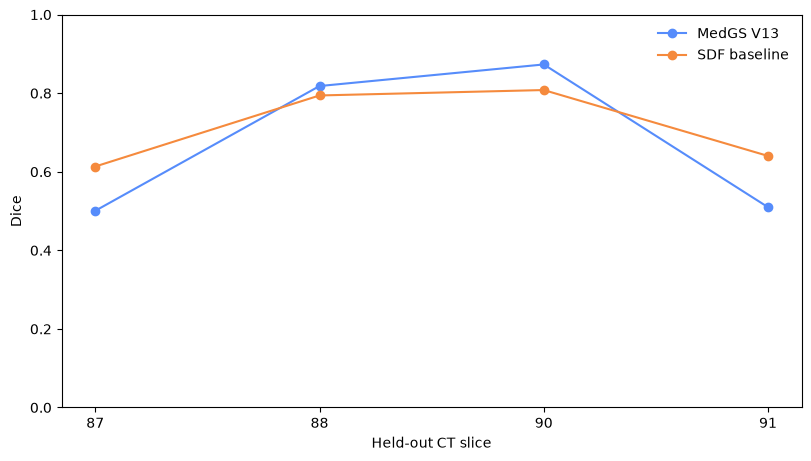

In [10]:
import matplotlib.pyplot as plt

print("Held-out tumor Dice: MedGS versus SDF.")

x = np.arange(
    len(tumor_missing_slices)
)

figure, axis = plt.subplots(
    figsize=(8, 4.5),
    constrained_layout=True,
)

axis.plot(
    x,
    per_slice_comparison["MedGS_Dice"],
    marker="o",
    label="MedGS V13",
)

axis.plot(
    x,
    per_slice_comparison["SDF_Dice"],
    marker="o",
    label="SDF baseline",
)

axis.set_xticks(
    x,
    [
        str(i)
        for i in tumor_missing_slices
    ],
)
axis.set_xlabel("Held-out CT slice")
axis.set_ylabel("Dice")
axis.set_ylim(0.0, 1.0)
axis.legend(frameon=False)

figure.savefig(
    SDF_EVAL_DIR
    / "heldout_dice_medgs_vs_sdf.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

Foreground extent: GT, MedGS and SDF.


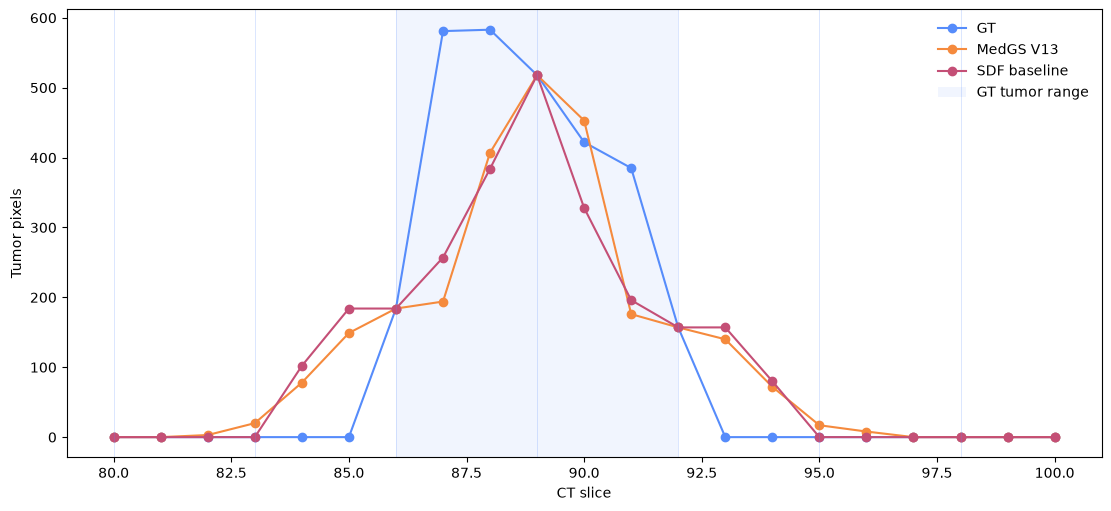

In [11]:
region_start = 80
region_end = 100

medgs_region = medgs_per_slice[
    medgs_per_slice["SliceIndex"].between(
        region_start,
        region_end,
    )
]

sdf_region = sdf_per_slice[
    sdf_per_slice["SliceIndex"].between(
        region_start,
        region_end,
    )
]

print("Foreground extent: GT, MedGS and SDF.")

figure, axis = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True,
)

axis.plot(
    sdf_region["SliceIndex"],
    sdf_region["GTPixels"],
    marker="o",
    label="GT",
)

axis.plot(
    medgs_region["SliceIndex"],
    medgs_region["PredictedPixels"],
    marker="o",
    label="MedGS V13",
)

axis.plot(
    sdf_region["SliceIndex"],
    sdf_region["PredictedPixels"],
    marker="o",
    label="SDF baseline",
)

for slice_index in observed_slices:
    if (
        region_start
        <= slice_index
        <= region_end
    ):
        axis.axvline(
            slice_index,
            linewidth=0.6,
            alpha=0.25,
        )

axis.axvspan(
    TUMOR_START,
    TUMOR_END,
    alpha=0.08,
    label="GT tumor range",
)

axis.set_xlabel("CT slice")
axis.set_ylabel("Tumor pixels")
axis.legend(frameon=False)

figure.savefig(
    SDF_EVAL_DIR
    / "foreground_medgs_vs_sdf.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

Held-out tumor contours: GT, MedGS and SDF.


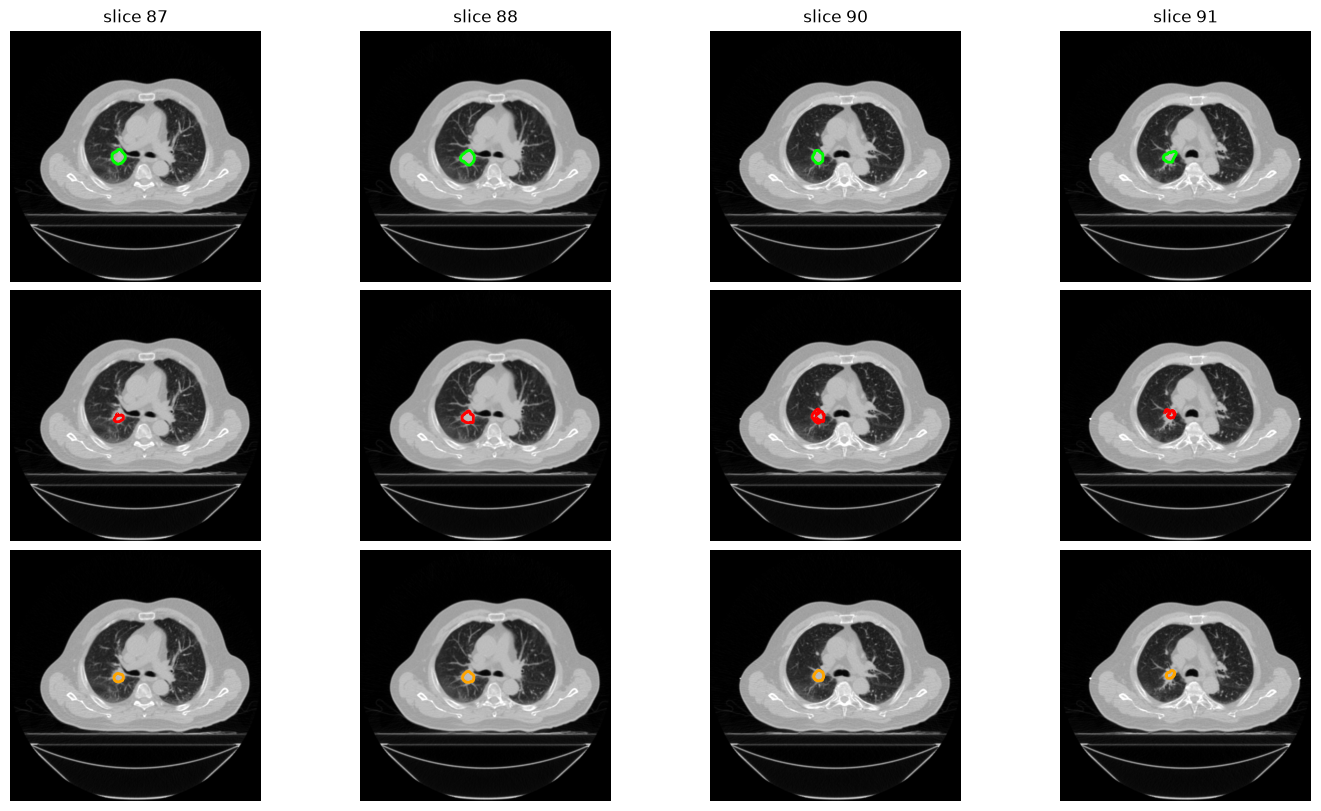

In [12]:
medgs_dense_mask_dir = (
    MEDGS_RUN / "dense_mask"
)

medgs_mask = np.stack(
    [
        np.asarray(
            Image.open(
                medgs_dense_mask_dir
                / f"{i:04d}.png"
            ).convert("L"),
            dtype=np.uint8,
        )
        >= 150
        for i in evaluation_slices
    ]
)

print("Held-out tumor contours: GT, MedGS and SDF.")

figure, axes = plt.subplots(
    3,
    len(tumor_missing_slices),
    figsize=(14, 8),
    constrained_layout=True,
)

for column, slice_index in enumerate(
    tumor_missing_slices
):
    ct_slice = window_hu_to_uint8(
        ct_hu[slice_index],
        study.hu_window,
    )

    for row in range(3):
        axes[row, column].imshow(
            ct_slice,
            cmap="gray",
        )
        axes[row, column].axis("off")

    axes[0, column].contour(
        reference_mask[slice_index],
        levels=[0.5],
        colors="lime",
        linewidths=2,
    )

    if medgs_mask[slice_index].any():
        axes[1, column].contour(
            medgs_mask[slice_index],
            levels=[0.5],
            colors="red",
            linewidths=2,
        )

    if predicted_mask[slice_index].any():
        axes[2, column].contour(
            predicted_mask[slice_index],
            levels=[0.5],
            colors="orange",
            linewidths=2,
        )

    axes[0, column].set_title(
        f"slice {slice_index}"
    )

axes[0, 0].set_ylabel(
    "GT",
    rotation=0,
    labelpad=20,
)

axes[1, 0].set_ylabel(
    "MedGS",
    rotation=0,
    labelpad=28,
)

axes[2, 0].set_ylabel(
    "SDF",
    rotation=0,
    labelpad=22,
)

figure.savefig(
    SDF_EVAL_DIR
    / "heldout_contours_medgs_vs_sdf.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 8. SDF mesh in anatomical context

The visualization below uses:

- green: reference tumor mesh from RTSTRUCT;
- red: reconstructed SDF baseline mesh.

This should be compared directly with the analogous MedGS visualization from the full-phase notebook.

In [13]:
print("Reference and SDF baseline tumor meshes.")

show_sparse_joint_anatomy_3d(
    PHASE_DIR,
    sdf_mesh,
)

Reference and SDF baseline tumor meshes.


# 9. Saved outputs

The SDF baseline is stored inside the completed full-phase MedGS experiment root under `sdf_baseline/`.

Saved artifacts include:

- the fixed baseline configuration;
- dense interpolated signed distance fields;
- reconstructed binary masks for all 147 slices;
- per-slice and split-level mask metrics;
- foreground-extent metrics;
- the mesh reconstructed with upstream MedGS `slices_to_ply.py`;
- 3D mesh metrics;
- the final MedGS-vs-SDF comparison table;
- publication-ready comparison figures.

No MedGS training is rerun by this notebook.

In [14]:
print("Saved SDF baseline root:", SDF_RUN)
print("Mask metrics:", SDF_EVAL_DIR / "mask_summary.csv")
print("Mesh metrics:", SDF_EVAL_DIR / "mesh_metrics.json")
print("Final comparison:", SDF_RUN / "medgs_vs_sdf.csv")

Saved SDF baseline root: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline
Mask metrics: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline/evaluation/mask_summary.csv
Mesh metrics: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline/evaluation/mesh_metrics.json
Final comparison: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/sdf_baseline/medgs_vs_sdf.csv
